In [28]:
!pip install -q pandas numpy matplotlib seaborn wordcloud openpyxl

In [29]:
import pandas as pd
import numpy as np
import re
import os
import zipfile
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from pathlib import Path
from wordcloud import WordCloud
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 250
plt.rcParams["font.size"] = 11

In [30]:
OUTPUT_DIR = Path("sprint1_outputs")
EDA_DIR = OUTPUT_DIR / "eda_figures"

OUTPUT_DIR.mkdir(exist_ok=True)
EDA_DIR.mkdir(exist_ok=True)

FILE_CANDIDATES = {
    "alfagift": [
        "alfagift_scrape.csv",
    ],
    "tokopedia": [
        "tokopedia_scrape.csv",
    ],
    "additional": [
        "additional_data - Sheet1.csv",
    ],
    "hangout_treats": [
        "hangout-treats-scrape.csv",
    ],
}

MASTER_OUTPUT = OUTPUT_DIR / "myfinance_sprint1_master_dataset.csv"
AI_OUTPUT = OUTPUT_DIR / "myfinance_ai_training_dataset.csv"
PRICE_OUTPUT = OUTPUT_DIR / "myfinance_price_only_dataset.csv"
REMOVED_OUTPUT = OUTPUT_DIR / "removed_rows_audit.csv"
SUMMARY_MASTER_OUTPUT = OUTPUT_DIR / "summary_by_master_category.csv"
SUMMARY_SOURCE_OUTPUT = OUTPUT_DIR / "summary_by_source.csv"
ZIP_OUTPUT = "sprint1_final_outputs.zip"


def resolve_file(candidates, keyword=None):
    for filename in candidates:
        if Path(filename).exists():
            return filename

    if keyword:
        matches = sorted(Path(".").glob(f"*{keyword}*.csv"))
        if matches:
            return str(matches[-1])

    raise FileNotFoundError(f"File tidak ditemukan. Kandidat: {candidates}")


resolved_files = {
    "alfagift": resolve_file(FILE_CANDIDATES["alfagift"], "alfagift"),
    "tokopedia": resolve_file(FILE_CANDIDATES["tokopedia"], "tokopedia"),
    "additional": resolve_file(FILE_CANDIDATES["additional"], "additional"),
    "hangout_treats": resolve_file(FILE_CANDIDATES["hangout_treats"], "hangout"),
}

resolved_files

{'alfagift': 'alfagift_scrape.csv',
 'tokopedia': 'tokopedia_scrape.csv',
 'additional': 'additional_data - Sheet1.csv',
 'hangout_treats': 'hangout-treats-scrape.csv'}

In [31]:
def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def get_col(df, possible_names, default=np.nan):
    for name in possible_names:
        if name in df.columns:
            return df[name]
    return pd.Series([default] * len(df), index=df.index)


def clean_text(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()
    x = re.sub(r"[\u2010-\u2015]", "-", x)
    x = re.sub(r"\s+", " ", x)
    x = x.strip()

    return x if x != "" else np.nan


def clean_price(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x in ["nan", "none", "", "-", "null"]:
        return np.nan

    x = re.sub(r"[^0-9]", "", x)

    if x == "":
        return np.nan

    return int(x)


def normalize_product_name(x):
    if pd.isna(x):
        return np.nan

    x = clean_text(x)

    if pd.isna(x):
        return np.nan

    x = re.sub(r"\s*-\s*tersedia.*$", "", x)
    x = re.sub(r"\s*-\s*tidak tersedia.*$", "", x)
    x = re.sub(r"\s*\|\s*.*$", "", x)

    x = re.sub(r"\+?\s*rp\s*[0-9\.\,]+.*$", "", x)
    x = re.sub(r"\brp\s*[0-9\.\,]+.*$", "", x)
    x = re.sub(r"\+\s*[0-9\.\,]+$", "", x)

    split_patterns = [
        r"\s+dengan\s+",
        r"\s+yang\s+",
        r"\s+berisi\s+",
        r"\s+terdiri dari\s+",
        r"\s+disajikan\s+",
        r"\s+dilengkapi\s+",
        r"\s+berbahan\s+",
        r"\s+terbuat dari\s+",
        r"\s+dipadukan\s+",
        r"\s+tulis di note\s+",
        r"\s+note\s+",
        r"\s+cocok\s+",
        r"\s+available\s+",
        r"\s+minimal order\s+",
        r"\s+pilihan\s+",
        r"\s+untuk\s+",
    ]

    if len(x) > 45:
        for pattern in split_patterns:
            parts = re.split(pattern, x, flags=re.IGNORECASE, maxsplit=1)
            if len(parts) > 1 and len(parts[0]) >= 4:
                x = parts[0]
                break

    x = re.sub(r"\s+(best seller|recommended|favorit|new menu|promo|menu baru).*$", "", x)
    x = re.sub(r"[^a-z0-9\s\+\&\.\-\/]", " ", x)
    x = re.sub(r"\s+", " ", x)
    x = x.strip(" ,-:|/+")

    return x if x != "" else np.nan


def is_bad_product_name(x):
    if pd.isna(x):
        return True

    x = str(x).strip().lower()

    if len(x) < 3:
        return True

    if len(x) > 85:
        return True

    if x.startswith(("+", "-")):
        return True

    if re.fullmatch(r"[0-9\.\,\s\/]+", x):
        return True

    if re.search(r"\brp\b", x):
        return True

    bad_keywords = [
        "penambahan", "tambahan", "tambah", "extra", "add on", "addon",
        "upgrade", "level", "opsi", "option", "pilihan", "pilih",
        "varian", "request", "harga tambahan", "topping", "toping",
        "sauce only", "saus only", "sauce", "saus", "sambal", "sambel",
        "bumbu", "level pedas", "note", "tulis di note", "available in",
        "free", "gratis", "beli di tempat", "mulai dari", "pack date",
        "exp date", "expired", "tersedia rasa", "bisa campur", "bisa pilih",
        "pilih rasa", "varian rasa", "sesuai selera", "minimal order",
        "nama menu", "harga menu", "daftar harga", "delivery", "gofood",
        "grabfood", "shopeefood", "menukuliner", "review", "rating",
        "alamat", "jam buka", "telepon", "cukup merogoh", "dibanderol",
        "disajikan", "berkisar", "pilihan menu", "di bawah ini",
        "berikut ini", "baca juga", "halaman", "lihat", "unknown",
    ]

    if any(k in x for k in bad_keywords):
        return True

    generic_single_words = {
        "boba", "kopi", "roti", "nasi", "keju", "oreo", "milo",
        "taro", "ice", "mix", "coke", "tape", "egg", "aqua",
        "jahe", "puff", "large", "medium", "small", "regular",
        "spicy", "original", "manis", "asin", "pedas", "dada",
        "paha", "sayap"
    }

    if len(x.split()) == 1 and x in generic_single_words:
        return True

    if re.search(r"\b(pack date|date\s+\d|[0-9]+\s*(gr|gram|kg)\b)", x):
        return True

    if x.count("+") >= 4 and not x.startswith(("paket", "combo")):
        return True

    return False

In [32]:
ALFAGIFT_SUBCATEGORY_MAP = {
    "perlengkapan dapur & ruang makan": "Kebutuhan Rumah & Mandi",
    "bahan masakan": "Makan & Minum Harian",
    "bahan roti & kue": "Makan & Minum Harian",
    "bahan puding & agar-agar": "Makan & Minum Harian",

    "makanan bayi & anak": "Makan & Minum Harian",
    "susu formula bayi & anak": "Makan & Minum Harian",
    "susu ibu hamil & menyusui": "Makan & Minum Harian",

    "perlengkapan mandi & perawatan anak": "Kebutuhan Rumah & Mandi",
    "popok bayi & anak": "Kebutuhan Rumah & Mandi",
    "pembersih pakaian & perlengkapan anak": "Kebutuhan Rumah & Mandi",
    "perlengkapan makan & minum anak": "Kebutuhan Rumah & Mandi",
    "kebutuhan ibu, bayi, & anak lainnya": "Kebutuhan Rumah & Mandi",

    "perlengkapan kamar mandi": "Kebutuhan Rumah & Mandi",
    "perawatan & pembersih": "Kebutuhan Rumah & Mandi",
    "perlengkapan rumah": "Kebutuhan Rumah & Mandi",
    "tisu": "Kebutuhan Rumah & Mandi",
    "pengharum ruangan & anti lembab": "Kebutuhan Rumah & Mandi",
    "pembasmi hama & serangga": "Kebutuhan Rumah & Mandi",

    "makanan ringan": "Jajan & Nongkrong",
    "minuman ringan": "Jajan & Nongkrong",
    "minuman siap saji": "Jajan & Nongkrong",
    "es krim": "Jajan & Nongkrong",

    "makanan instan": "Makan & Minum Harian",
    "roti, selai, & sereal": "Makan & Minum Harian",
    "produk olahan susu": "Makan & Minum Harian",
    "minuman instan": "Makan & Minum Harian",
    "makanan siap saji": "Makan & Minum Harian",
    "makanan segar": "Makan & Minum Harian",
    "makanan beku": "Makan & Minum Harian",
    "makanan kemasan": "Makan & Minum Harian",

    "peralatan rias & tata rambut": "Hobi & Self-Reward",
    "perawatan wajah": "Hobi & Self-Reward",
    "riasan wajah & tubuh": "Hobi & Self-Reward",
    "parfum & cologne": "Hobi & Self-Reward",

    "perawatan tubuh": "Kebutuhan Rumah & Mandi",
    "perawatan pria": "Kebutuhan Rumah & Mandi",
    "perawatan rambut": "Kebutuhan Rumah & Mandi",
    "pembalut & popok dewasa": "Kebutuhan Rumah & Mandi",
    "perawatan gigi & mulut": "Kebutuhan Rumah & Mandi",
    "produk higienis": "Kebutuhan Rumah & Mandi",

    "obat-obatan": "Lain-lain & Darurat",
    "vitamin & suplemen": "Lain-lain & Darurat",
    "alat kesehatan": "Lain-lain & Darurat",

    "mainan & hiburan": "Hobi & Self-Reward",
    "fashion": "Hobi & Self-Reward",

    "perlengkapan kantor & sekolah": "Lain-lain & Darurat",
    "perlengkapan otomotif": "Transportasi & Rutinitas",

    "makanan anjing": "Lain-lain & Darurat",
    "makanan kucing": "Lain-lain & Darurat",
    "makanan hewan peliharan lainnya": "Lain-lain & Darurat",
}


def infer_hangout_refined_category(product_name, raw_category):
    text = f"{product_name} {raw_category}".lower()

    if any(k in text for k in ["popcorn", "hotdog", "fries", "siomay", "sausage", "sampler"]):
        return "movie snack"

    if any(k in text for k in ["soft drink", "lemon tea", "milo", "soda"]):
        return "movie drink"

    if any(k in text for k in ["xxi", "cgv", "cinepolis", "bioskop", "cinema", "tiket", "premiere", "imax", "sweetbox"]):
        return "cinema ticket"

    if any(k in text for k in ["boba", "brown sugar", "bubble"]):
        return "boba"

    if any(k in text for k in ["milk tea", "thai tea", "cheese tea"]):
        return "milk tea"

    if any(k in text for k in ["matcha", "green tea", "greentea", "hojicha"]):
        return "matcha / tea"

    if any(k in text for k in ["kopi", "coffee", "latte", "americano", "espresso", "cappuccino", "macchiato", "mocha", "cold brew", "aren"]):
        return "coffee"

    if any(k in text for k in ["choco", "coklat", "milo", "red velvet", "taro", "chocolate"]):
        return "non-coffee drink"

    if any(k in text for k in ["burger", "cheeseburger", "hotdog", "sandwich", "whopper"]):
        return "burger / sandwich"

    if "pizza" in text:
        return "pizza"

    if any(k in text for k in ["fried chicken", "crispy chicken", "ayam goreng", "kfc", "richeese", "wing", "wings", "fire chicken"]):
        return "fried chicken"

    if any(k in text for k in ["fries", "kentang", "nugget", "nuggets", "sosis", "otak"]):
        return "snack"

    if any(k in text for k in ["roti bakar", "ropang", "toast"]):
        return "roti bakar / toast"

    if "croffle" in text:
        return "croffle"

    if "waffle" in text:
        return "waffle"

    if "pancake" in text:
        return "pancake"

    if any(k in text for k in ["dessert", "cheesecake", "cake", "brownies", "pudding", "puding", "tiramisu"]):
        return "dessert"

    if any(k in text for k in ["bakery", "roti", "croissant", "donut", "donat", "pastry", "muffin", "bun"]):
        return "bakery"

    if any(k in text for k in ["ice cream", "es krim", "gelato"]):
        return "ice cream"

    if any(k in text for k in ["paket", "combo", "meal", "box"]):
        return "combo meal"

    return clean_text(raw_category)


def infer_master_category(source, raw_category, raw_subcategory, product_name):
    source = str(source).lower()
    raw_category = clean_text(raw_category)
    raw_subcategory = clean_text(raw_subcategory)
    product_name = clean_text(product_name)

    text = f"{source} {raw_category} {raw_subcategory} {product_name}".lower()

    if source == "hangout_treats":
        return "Jajan & Nongkrong"

    if source == "additional":
        if any(k in text for k in ["transport", "gojek", "grab", "mrt", "transjakarta", "kereta", "krl", "lrt", "brt", "becak", "ferry", "pesawat", "damri", "bus", "angkot"]):
            return "Transportasi & Rutinitas"

        if any(k in text for k in ["hangout", "treat", "jajan", "shopeefood", "bioskop", "film"]):
            return "Jajan & Nongkrong"

        if any(k in text for k in ["lifestyle", "baju", "celana", "skincare", "sepatu"]):
            return "Hobi & Self-Reward"

    if source == "tokopedia":
        if any(k in text for k in ["voucher games", "mobile game", "pc game", "streaming", "entertainment", "belajar", "voucher", "game"]):
            return "Hobi & Self-Reward"

        if any(k in text for k in ["prabayar", "pascabayar", "bayar", "isi ulang", "layanan pemerintah", "pulsa", "pln", "pdam", "bpjs", "pajak", "tagihan", "internet", "asuransi", "angsuran", "properti", "telkom"]):
            return "Tagihan & Kewajiban"

        if any(k in text for k in ["donasi", "zakat"]):
            return "Lain-lain & Darurat"

    if source == "alfagift":
        if raw_subcategory in ALFAGIFT_SUBCATEGORY_MAP:
            return ALFAGIFT_SUBCATEGORY_MAP[raw_subcategory]

    if any(k in text for k in ["kopi", "coffee", "boba", "snack", "makanan ringan", "minuman ringan", "es krim", "coklat", "cokelat", "permen"]):
        return "Jajan & Nongkrong"

    if any(k in text for k in ["beras", "minyak", "gula", "susu", "makanan instan", "makanan segar", "makanan beku", "bahan masakan"]):
        return "Makan & Minum Harian"

    if any(k in text for k in ["deterjen", "sabun", "shampoo", "sampo", "pembersih", "tisu", "popok", "pembalut", "perawatan tubuh", "perawatan rambut", "perawatan gigi"]):
        return "Kebutuhan Rumah & Mandi"

    if any(k in text for k in ["skincare", "makeup", "riasan", "parfum", "fashion", "mainan", "hiburan"]):
        return "Hobi & Self-Reward"

    if any(k in text for k in ["obat", "vitamin", "suplemen", "kesehatan"]):
        return "Lain-lain & Darurat"

    return "Lain-lain & Darurat"


def infer_macro_category(master_category):
    needs = {
        "Makan & Minum Harian",
        "Kebutuhan Rumah & Mandi",
        "Tagihan & Kewajiban",
        "Transportasi & Rutinitas",
    }

    wants = {
        "Jajan & Nongkrong",
        "Hobi & Self-Reward",
    }

    if master_category in needs:
        return "NEEDS"

    if master_category in wants:
        return "WANTS"

    return "OTHERS"


def infer_refined_raw_category(source, master_category, raw_category, raw_subcategory, product_name):
    text = f"{raw_category} {raw_subcategory} {product_name}".lower()

    if source == "hangout_treats":
        return infer_hangout_refined_category(product_name, raw_category)

    if master_category == "Makan & Minum Harian":
        return "daily food"

    if master_category == "Kebutuhan Rumah & Mandi":
        return "household & personal care"

    if master_category == "Tagihan & Kewajiban":
        return "bills & obligations"

    if master_category == "Transportasi & Rutinitas":
        return "transport"

    if master_category == "Hobi & Self-Reward":
        if any(k in text for k in ["game", "streaming", "voucher", "entertainment"]):
            return "digital entertainment"
        if any(k in text for k in ["fashion", "baju", "celana", "sepatu"]):
            return "fashion"
        if any(k in text for k in ["skincare", "makeup", "riasan", "parfum"]):
            return "beauty / self care"
        return "lifestyle / self reward"

    if master_category == "Jajan & Nongkrong":
        return infer_hangout_refined_category(product_name, raw_category)

    return "others"

In [33]:
def load_alfagift(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)

    return pd.DataFrame({
        "source": "alfagift",
        "raw_category": get_col(df, ["category"]),
        "raw_subcategory": get_col(df, ["subcategory"]),
        "product_name_raw": get_col(df, ["product", "name", "product_name"]),
        "price": get_col(df, ["price", "harga"]),
    })


def load_tokopedia(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)

    return pd.DataFrame({
        "source": "tokopedia",
        "raw_category": get_col(df, ["category"]),
        "raw_subcategory": get_col(df, ["subcategory"]),
        "product_name_raw": get_col(df, ["nama_produk", "product", "name", "product_name"]),
        "price": np.nan,
    })


def load_additional(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)

    return pd.DataFrame({
        "source": "additional",
        "raw_category": get_col(df, ["master_category", "category"]),
        "raw_subcategory": get_col(df, ["subcategory"]),
        "product_name_raw": get_col(df, ["name", "product", "product_name"]),
        "price": np.nan,
    })


def load_hangout(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)

    return pd.DataFrame({
        "source": "hangout_treats",
        "raw_category": get_col(df, ["category"]),
        "raw_subcategory": get_col(df, ["raw_category", "subcategory"]),
        "product_name_raw": get_col(df, ["product_name", "menu_name", "product_clean", "item_name"]),
        "price": get_col(df, ["price", "harga"]),
    })


df_raw = pd.concat(
    [
        load_alfagift(resolved_files["alfagift"]),
        load_tokopedia(resolved_files["tokopedia"]),
        load_additional(resolved_files["additional"]),
        load_hangout(resolved_files["hangout_treats"]),
    ],
    ignore_index=True
)

print("Raw merged shape:", df_raw.shape)
display(df_raw.head())
display(df_raw["source"].value_counts())

Raw merged shape: (13262, 5)


,source,raw_category,raw_subcategory,product_name_raw,price
0,alfagift,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Sedotan Plastik Flexibel 50 pcs,10.900
1,alfagift,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Sarung Tangan Plastik 100 pcs,14.500
2,alfagift,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Alfamart Piring Plastik 20 pcs,19.100
3,alfagift,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,Bright Tabung Gas Elpiji (Kosong) 5.5 kg,330.000
4,alfagift,Kebutuhan Dapur,Perlengkapan Dapur & Ruang Makan,SGI Botol Minum Warna Warni Assorted 530 ml,29.900


,count
source,
alfagift,9433
hangout_treats,3639
tokopedia,170
additional,20


In [34]:
def get_drop_reason(row):
    product = row["product_clean"]

    if is_bad_product_name(product):
        return "bad_product_name"

    source = row["source"]
    master = row["Master_Category"]

    if source == "hangout_treats":
        text = str(product).lower()
        category_text = f"{row['raw_category']} {row['raw_subcategory']} {product}".lower()

        positive_hangout = [
            "kopi", "coffee", "latte", "americano", "espresso", "cappuccino",
            "macchiato", "mocha", "cold brew", "boba", "milk tea", "thai tea",
            "matcha", "hojicha", "green tea", "choco", "coklat", "milo",
            "taro", "red velvet", "tea", "susu", "aren", "frappe",
            "smoothie", "yakult", "lemon", "lychee", "mangga", "avocado",
            "chocolate", "roti", "toast", "ropang", "croffle", "waffle",
            "pancake", "dessert", "cake", "cheesecake", "brownies", "cookie",
            "cookies", "croissant", "pastry", "bakery", "donat", "donut",
            "kentang", "fries", "sosis", "otak", "pisang", "martabak",
            "es krim", "ice cream", "gelato", "burger", "pizza",
            "fried chicken", "crispy chicken", "ayam goreng", "kfc", "mcd",
            "mcdonald", "burger king", "richeese", "pizza hut", "phd",
            "nugget", "nuggets", "wing", "wings", "hotdog", "sandwich",
            "combo", "paket", "meal", "box", "xxi", "cgv", "cinepolis",
            "bioskop", "cinema", "tiket", "regular", "premiere", "imax",
            "satin", "sweetbox", "popcorn", "soft drink", "lemon tea",
            "sampler"
        ]

        negative_hangout = [
            "soto", "bakso", "rawon", "gudeg", "pecel", "capcay", "gurame",
            "cumi", "ikan", "bebek", "karedok", "sayur", "tumis", "oseng",
            "pare", "tempe tahu", "mie pangsit", "bakmi", "dimsum", "gyoza"
        ]

        if any(k in text for k in negative_hangout):
            return "hangout_noise_food_home_meal"

        if not any(k in category_text for k in positive_hangout):
            return "hangout_not_relevant"

    if row["price"] is not np.nan and not pd.isna(row["price"]):
        if row["price"] < 1000 or row["price"] > 5000000:
            return "price_out_of_range"

    return None


def infer_label_confidence(row):
    source = row["source"]
    master = row["Master_Category"]
    raw_sub = str(row["raw_subcategory"]).lower()
    product = str(row["product_clean"]).lower()

    if source == "hangout_treats":
        return "high"

    if source == "additional":
        return "high"

    if source == "tokopedia":
        return "high"

    if source == "alfagift" and raw_sub in ALFAGIFT_SUBCATEGORY_MAP:
        return "high"

    if master == "Lain-lain & Darurat":
        return "medium"

    if len(product.split()) <= 1:
        return "medium"

    return "medium"

In [35]:
df = df_raw.copy()

df["raw_category"] = df["raw_category"].apply(clean_text)
df["raw_subcategory"] = df["raw_subcategory"].apply(clean_text)

df["product_clean"] = df["product_name_raw"].apply(normalize_product_name)
df["price"] = df["price"].apply(clean_price)
df["price_missing"] = df["price"].isna()
df["has_price"] = ~df["price_missing"]

df["Master_Category"] = df.apply(
    lambda row: infer_master_category(
        source=row["source"],
        raw_category=row["raw_category"],
        raw_subcategory=row["raw_subcategory"],
        product_name=row["product_clean"]
    ),
    axis=1
)

df["Macro_Category"] = df["Master_Category"].apply(infer_macro_category)

df["raw_category_refined"] = df.apply(
    lambda row: infer_refined_raw_category(
        source=row["source"],
        master_category=row["Master_Category"],
        raw_category=row["raw_category"],
        raw_subcategory=row["raw_subcategory"],
        product_name=row["product_clean"]
    ),
    axis=1
)

df["drop_reason"] = df.apply(get_drop_reason, axis=1)
df_removed = df[df["drop_reason"].notna()].copy()
df_clean = df[df["drop_reason"].isna()].copy()

df_clean["label_confidence"] = df_clean.apply(infer_label_confidence, axis=1)
df_clean["is_ai_ready"] = df_clean["label_confidence"].isin(["high", "medium"])

df_clean["name_length"] = df_clean["product_clean"].str.len()
df_clean["word_count"] = df_clean["product_clean"].str.split().str.len()
df_clean["contains_number"] = df_clean["product_clean"].str.contains(r"\d", regex=True, na=False)

size_extract = df_clean["product_clean"].str.extract(
    r"(?P<size_value>\d+(?:[\.,]\d+)?)\s*(?P<size_unit>ml|l|lt|liter|g|gr|gram|kg|pcs|pc|pack|sachet|tablet|capsule|kapsul)"
)

df_clean["size_value"] = pd.to_numeric(
    size_extract["size_value"].str.replace(",", ".", regex=False),
    errors="coerce"
)
df_clean["size_unit"] = size_extract["size_unit"]

df_clean["price_bin"] = pd.cut(
    df_clean["price"],
    bins=[0, 10000, 25000, 50000, 100000, 250000, 500000, np.inf],
    labels=["0-10k", "10k-25k", "25k-50k", "50k-100k", "100k-250k", "250k-500k", ">500k"]
)

df_clean = df_clean.sort_values(
    by=["price_missing", "label_confidence", "source"],
    ascending=[True, True, True]
)

df_clean = df_clean.drop_duplicates(
    subset=["product_clean", "price", "Master_Category"],
    keep="first"
).reset_index(drop=True)

MASTER_COLUMNS = [
    "source",
    "raw_category",
    "raw_subcategory",
    "raw_category_refined",
    "product_name_raw",
    "product_clean",
    "price",
    "price_missing",
    "has_price",
    "price_bin",
    "name_length",
    "word_count",
    "contains_number",
    "size_value",
    "size_unit",
    "Macro_Category",
    "Master_Category",
    "label_confidence",
    "is_ai_ready",
]

df_master = df_clean[MASTER_COLUMNS].copy()

df_ai = df_master[df_master["is_ai_ready"] == True][
    [
        "product_clean",
        "price",
        "price_missing",
        "raw_category_refined",
        "Macro_Category",
        "Master_Category",
        "label_confidence",
        "source",
    ]
].copy()

df_price_only = df_master[df_master["price_missing"] == False].copy()

df_master.to_csv(MASTER_OUTPUT, index=False)
df_ai.to_csv(AI_OUTPUT, index=False)
df_price_only.to_csv(PRICE_OUTPUT, index=False)
df_removed.to_csv(REMOVED_OUTPUT, index=False)

print("=" * 90)
print("DATA WRANGLING & PREPROCESSING SELESAI")
print("=" * 90)
print(f"Raw rows        : {len(df_raw):,}")
print(f"Removed rows    : {len(df_removed):,}")
print(f"Master rows     : {len(df_master):,}")
print(f"AI-ready rows   : {len(df_ai):,}")
print(f"Price rows      : {len(df_price_only):,}")
print(f"Missing price   : {df_master['price_missing'].sum():,}")
print(f"Master output   : {MASTER_OUTPUT}")
print(f"AI output       : {AI_OUTPUT}")

display(df_master.head(20))

DATA WRANGLING & PREPROCESSING SELESAI
Raw rows        : 13,262
Removed rows    : 733
Master rows     : 12,429
AI-ready rows   : 12,429
Price rows      : 10,969
Missing price   : 1,460
Master output   : sprint1_outputs/myfinance_sprint1_master_dataset.csv
AI output       : sprint1_outputs/myfinance_ai_training_dataset.csv


,source,raw_category,raw_subcategory,raw_category_refined,product_name_raw,product_clean,price,price_missing,has_price,price_bin,name_length,word_count,contains_number,size_value,size_unit,Macro_Category,Master_Category,label_confidence,is_ai_ready
0,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Alfamart Sedotan Plastik Flexibel 50 pcs,alfamart sedotan plastik flexibel 50 pcs,10900.0,False,True,10k-25k,40,6,True,50.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True
1,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Alfamart Sarung Tangan Plastik 100 pcs,alfamart sarung tangan plastik 100 pcs,14500.0,False,True,10k-25k,38,6,True,100.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True
2,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Alfamart Piring Plastik 20 pcs,alfamart piring plastik 20 pcs,19100.0,False,True,10k-25k,30,5,True,20.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True
3,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,SGI Botol Minum Warna Warni Assorted 530 ml,sgi botol minum warna warni assorted 530 ml,29900.0,False,True,25k-50k,43,8,True,530.0,ml,NEEDS,Kebutuhan Rumah & Mandi,high,True
4,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,SGI Botol Minum Bola 530 ml,sgi botol minum bola 530 ml,29900.0,False,True,25k-50k,27,6,True,530.0,ml,NEEDS,Kebutuhan Rumah & Mandi,high,True
5,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Hi-Cook Tabung Gas Mini Portabel 230 g,hi-cook tabung gas mini portabel 230 g,26500.0,False,True,25k-50k,38,7,True,230.0,g,NEEDS,Kebutuhan Rumah & Mandi,high,True
6,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Gema Tabung Gas Mini Portabel 250 g,gema tabung gas mini portabel 250 g,25500.0,False,True,25k-50k,35,7,True,250.0,g,NEEDS,Kebutuhan Rumah & Mandi,high,True
7,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Wonder Fuel Tabung Gas Mini Portabel 220 g,wonder fuel tabung gas mini portabel 220 g,25900.0,False,True,25k-50k,42,8,True,220.0,g,NEEDS,Kebutuhan Rumah & Mandi,high,True
8,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Alfamart Tempat Makan 750 ml 5 pcs,alfamart tempat makan 750 ml 5 pcs,17900.0,False,True,10k-25k,34,7,True,750.0,ml,NEEDS,Kebutuhan Rumah & Mandi,high,True
9,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,household & personal care,Alfamart Gelas Kertas Kecil 15 pcs,alfamart gelas kertas kecil 15 pcs,18500.0,False,True,10k-25k,34,6,True,15.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True


In [36]:
print("Removed rows by reason:")
display(df_removed["drop_reason"].value_counts().to_frame("removed_rows"))

print("Label confidence:")
display(df_master["label_confidence"].value_counts().to_frame("rows"))

print("Macro Category:")
display(df_master["Macro_Category"].value_counts().to_frame("rows"))

print("Master Category:")
display(df_master["Master_Category"].value_counts().to_frame("rows"))

print("Sample removed rows:")
audit_cols = ["source", "raw_category", "raw_subcategory", "product_name_raw", "product_clean", "price", "drop_reason"]

available_audit_cols = [c for c in audit_cols if c in df_removed.columns]
display(df_removed[available_audit_cols].head(50))

print("Random sample final dataset:")
display(df_master.sample(min(50, len(df_master)), random_state=42))

Removed rows by reason:


,removed_rows
drop_reason,
bad_product_name,707
hangout_noise_food_home_meal,26


Label confidence:


,rows
label_confidence,
high,12429


Macro Category:


...

,rows
Master_Category,
Jajan & Nongkrong,5637
Kebutuhan Rumah & Mandi,2411
Makan & Minum Harian,2369
Hobi & Self-Reward,1243
Lain-lain & Darurat,645
Transportasi & Rutinitas,81
Tagihan & Kewajiban,43


Sample removed rows:


,source,raw_category,raw_subcategory,product_name_raw,product_clean,price,drop_reason
3,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Tabung Gas Elpiji (Kosong) 5.5 kg,bright tabung gas elpiji kosong 5.5 kg,330000.0,bad_product_name
12,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Gas Elpiji (Refill) 5.5 kg (C),bright gas elpiji refill 5.5 kg c,NaN,bad_product_name
13,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Tabung Gas Elpiji (Kosong) 12 kg (A),bright tabung gas elpiji kosong 12 kg a,NaN,bad_product_name
14,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Gas Elpiji (Refill) 5.5 kg (B),bright gas elpiji refill 5.5 kg b,NaN,bad_product_name
15,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Gas Elpiji (Refill) 12 kg (C),bright gas elpiji refill 12 kg c,NaN,bad_product_name
16,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Gas Elpiji (Refill) 12 kg (B),bright gas elpiji refill 12 kg b,NaN,bad_product_name
23,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Alfamart Disney Chopper Bumbu Mickey Mouse Ass...,alfamart disney chopper bumbu mickey mouse ass...,NaN,bad_product_name
24,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Tabung Gas Elpiji (Kosong) 5.5 kg (A),bright tabung gas elpiji kosong 5.5 kg a,NaN,bad_product_name
26,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Bright Gas Elpiji (Refill) 5.5 kg (A),bright gas elpiji refill 5.5 kg a,NaN,bad_product_name
28,alfagift,kebutuhan dapur,perlengkapan dapur & ruang makan,Freemir Set Teko & Cangkir 5 pcs,freemir set teko & cangkir 5 pcs,NaN,bad_product_name


Random sample final dataset:


,source,raw_category,raw_subcategory,raw_category_refined,product_name_raw,product_clean,price,price_missing,has_price,price_bin,name_length,word_count,contains_number,size_value,size_unit,Macro_Category,Master_Category,label_confidence,is_ai_ready
12278,tokopedia,bayar,NaN,bills & obligations,Langganan,langganan,NaN,True,False,NaN,9,1,False,NaN,NaN,NEEDS,Tagihan & Kewajiban,high,True
9622,hangout_treats,snack_dessert,bakery,dessert,1bungkus jamur shimeji,1bungkus jamur shimeji,18000.0,False,True,10k-25k,22,3,True,NaN,NaN,WANTS,Jajan & Nongkrong,high,True
11161,alfagift,kebutuhan rumah,perlengkapan rumah,household & personal care,ABC Baterai AA Biru R-6 4 pcs,abc baterai aa biru r-6 4 pcs,NaN,True,False,NaN,29,7,True,4.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True
12385,tokopedia,voucher games,entertainment,digital entertainment,StarMaker (Global),starmaker global,NaN,True,False,NaN,16,2,False,NaN,NaN,WANTS,Hobi & Self-Reward,high,True
12033,alfagift,personal care,perawatan pria,household & personal care,Himalaya Herbals Men Pembersih Wajah Intense O...,himalaya herbals men pembersih wajah intense o...,NaN,True,False,NaN,67,11,True,100.0,ml,NEEDS,Kebutuhan Rumah & Mandi,high,True
2439,alfagift,makanan,makanan ringan,makanan,Chiki Balls Makanan Ringan Cheeky Chicken 50 g,chiki balls makanan ringan cheeky chicken 50 g,7200.0,False,True,0-10k,46,8,True,50.0,g,WANTS,Jajan & Nongkrong,high,True
5928,alfagift,personal care,riasan wajah & tubuh,beauty / self care,Wardah Glasting Lip Liquid 02 Peach Polish 3.5 g,wardah glasting lip liquid 02 peach polish 3.5 g,83000.0,False,True,50k-100k,48,9,True,3.5,g,WANTS,Hobi & Self-Reward,high,True
1114,alfagift,kebutuhan ibu & anak,popok bayi & anak,household & personal care,Makuku SAP Comfort Fit Popok Perekat Bayi NB 4...,makuku sap comfort fit popok perekat bayi nb 4...,52900.0,False,True,50k-100k,51,10,True,40.0,pcs,NEEDS,Kebutuhan Rumah & Mandi,high,True
12179,alfagift,lifestyle,mainan & hiburan,lifestyle / self reward,Disney Puzzle Mainan Anak D100S1 Assorted,disney puzzle mainan anak d100s1 assorted,NaN,True,False,NaN,41,6,True,NaN,NaN,WANTS,Hobi & Self-Reward,high,True
8736,hangout_treats,cafe_drinks,milk tea,milk tea,perpaduan thai tea ala kopi kanto denganyakult...,perpaduan thai tea ala kopi kanto denganyakult...,21000.0,False,True,10k-25k,62,10,False,NaN,NaN,WANTS,Jajan & Nongkrong,high,True


In [37]:
summary_by_master = (
    df_master
    .groupby(["Macro_Category", "Master_Category"])
    .agg(
        total_rows=("product_clean", "count"),
        unique_products=("product_clean", "nunique"),
        valid_price_rows=("price", lambda x: x.notna().sum()),
        missing_price_rows=("price", lambda x: x.isna().sum()),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        high_confidence_rows=("label_confidence", lambda x: (x == "high").sum()),
    )
    .reset_index()
)

summary_by_source = (
    df_master
    .groupby("source")
    .agg(
        total_rows=("product_clean", "count"),
        unique_products=("product_clean", "nunique"),
        valid_price_rows=("price", lambda x: x.notna().sum()),
        missing_price_rows=("price", lambda x: x.isna().sum()),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .reset_index()
)

summary_by_master.to_csv(SUMMARY_MASTER_OUTPUT, index=False)
summary_by_source.to_csv(SUMMARY_SOURCE_OUTPUT, index=False)

display(summary_by_master)
display(summary_by_source)

,Macro_Category,Master_Category,total_rows,unique_products,valid_price_rows,missing_price_rows,median_price,mean_price,min_price,max_price,high_confidence_rows
0,NEEDS,Kebutuhan Rumah & Mandi,2411,2401,2253,158,26500.0,34137.905016,2500.0,279900.0,2411
1,NEEDS,Makan & Minum Harian,2369,2361,1803,566,16500.0,39723.128120,2400.0,1085000.0,2369
2,NEEDS,Tagihan & Kewajiban,43,43,0,43,NaN,NaN,NaN,NaN,43
3,NEEDS,Transportasi & Rutinitas,81,81,67,14,26900.0,29426.865672,7000.0,100000.0,81
4,OTHERS,Lain-lain & Darurat,645,644,562,83,17500.0,28259.074733,1700.0,277700.0,645
5,WANTS,Hobi & Self-Reward,1243,1234,989,254,36900.0,51277.704752,1000.0,359000.0,1243
6,WANTS,Jajan & Nongkrong,5637,5168,5295,342,16000.0,24885.578848,1500.0,465000.0,5637


,source,total_rows,unique_products,valid_price_rows,missing_price_rows,median_price,mean_price,min_price,max_price
0,additional,19,19,0,19,NaN,NaN,NaN,NaN
1,alfagift,8636,8588,7359,1277,19500.0,32608.472619,1000.0,1085000.0
2,hangout_treats,3610,3161,3610,0,20000.0,30167.240997,3000.0,465000.0
3,tokopedia,164,164,0,164,NaN,NaN,NaN,NaN


In [38]:
def rupiah_formatter(x, pos=None):
    if pd.isna(x):
        return ""
    return f"Rp {int(x):,}".replace(",", ".")


def add_bar_labels(ax, fmt="{:,.0f}", padding=4):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append("")
            else:
                labels.append(fmt.format(value).replace(",", "."))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=9)


def save_plot(filename):
    plt.tight_layout()
    plt.savefig(EDA_DIR / filename, bbox_inches="tight")
    plt.show()


def shorten_text(x, max_len=42):
    x = str(x)
    if len(x) <= max_len:
        return x
    return x[:max_len] + "..."

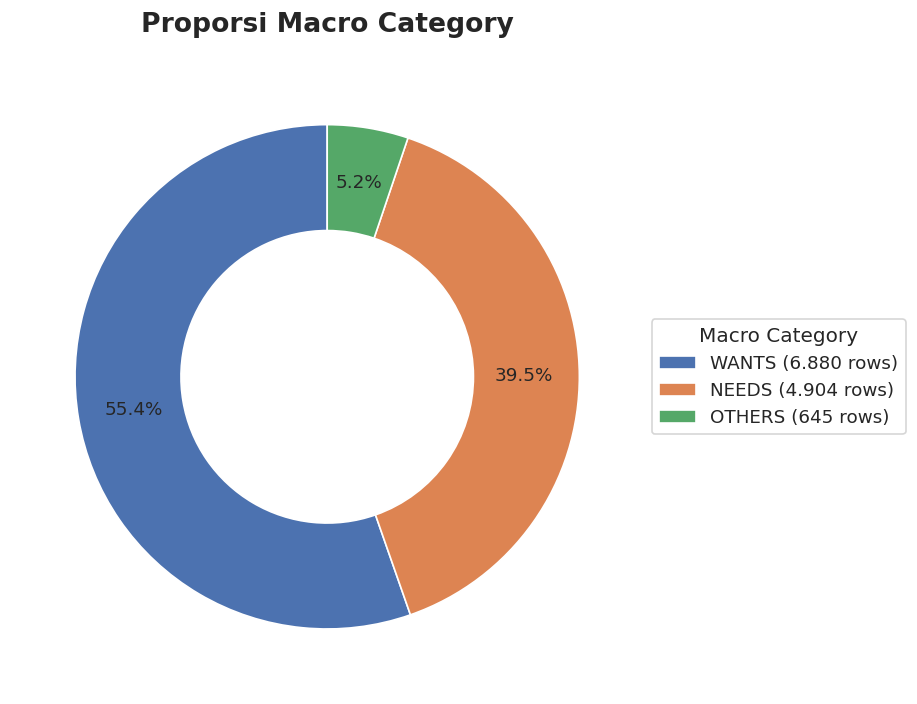

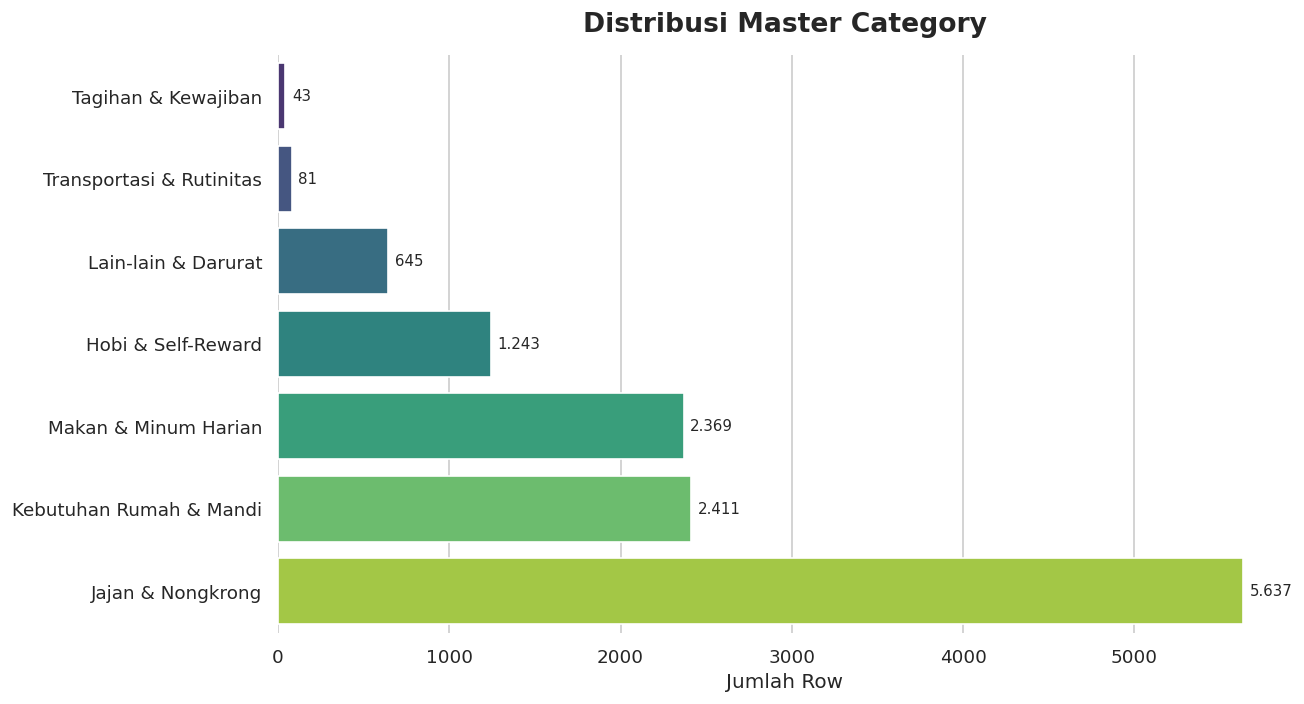

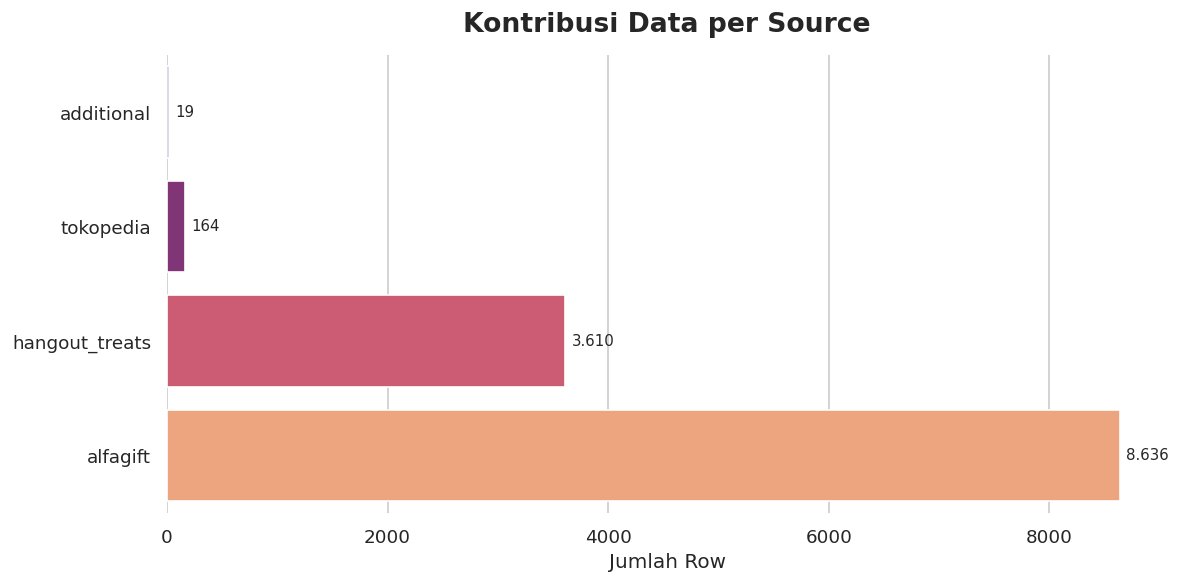

In [48]:
macro_counts = df_master["Macro_Category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    macro_counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

ax.set_title("Proporsi Macro Category", fontsize=16, fontweight="bold", pad=18)
ax.legend(
    wedges,
    [f"{idx} ({val:,} rows)".replace(",", ".") for idx, val in macro_counts.items()],
    title="Macro Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

save_plot("01_macro_category_donut.png")

master_counts = df_master["Master_Category"].value_counts().sort_values()

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=master_counts.values,
    y=master_counts.index,
    hue=master_counts.index,
    legend=False,
    palette="viridis"
)

ax.set_title("Distribusi Master Category", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah Row")
ax.set_ylabel("")
add_bar_labels(ax)
sns.despine(left=True, bottom=True)
save_plot("02_master_category_distribution.png")

source_counts = df_master["source"].value_counts().sort_values()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=source_counts.values,
    y=source_counts.index,
    hue=source_counts.index,
    legend=False,
    palette="magma"
)

ax.set_title("Kontribusi Data per Source", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah Row")
ax.set_ylabel("")
add_bar_labels(ax)
sns.despine(left=True, bottom=True)
save_plot("03_source_distribution.png")

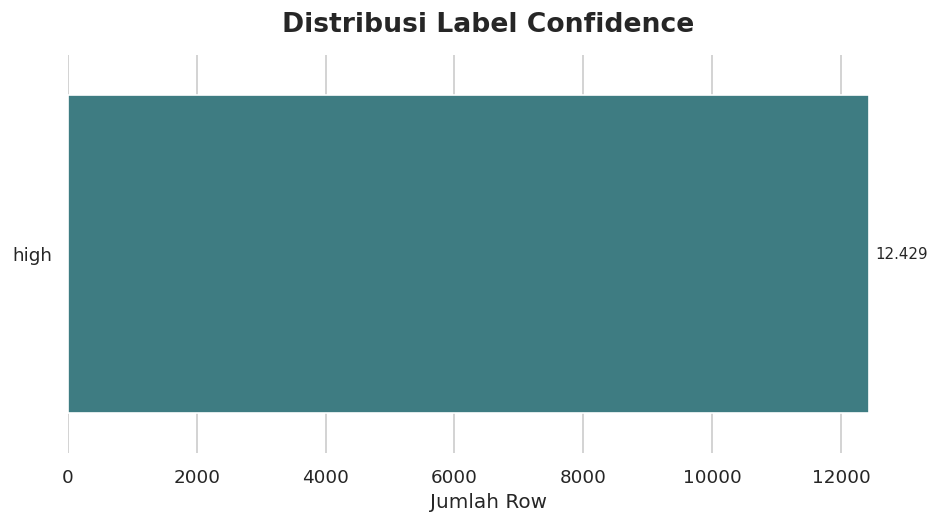

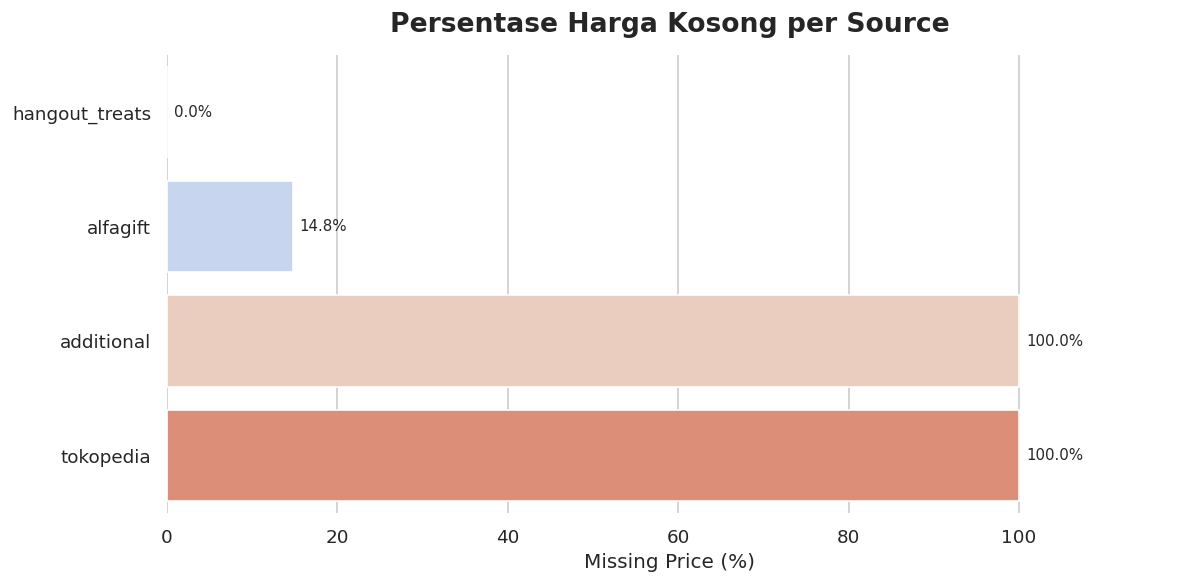

In [49]:
confidence_counts = df_master["label_confidence"].value_counts().sort_values()

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    x=confidence_counts.values,
    y=confidence_counts.index,
    hue=confidence_counts.index,
    legend=False,
    palette="crest"
)

ax.set_title("Distribusi Label Confidence", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah Row")
ax.set_ylabel("")
add_bar_labels(ax)
sns.despine(left=True, bottom=True)
save_plot("04_label_confidence_distribution.png")

missing_by_source = (
    df_master
    .groupby("source")
    .agg(
        total_rows=("product_clean", "count"),
        missing_rows=("price_missing", "sum")
    )
    .reset_index()
)

missing_by_source["missing_rate"] = missing_by_source["missing_rows"] / missing_by_source["total_rows"] * 100
missing_by_source = missing_by_source.sort_values("missing_rate")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=missing_by_source,
    x="missing_rate",
    y="source",
    hue="source",
    legend=False,
    palette="coolwarm"
)

ax.set_title("Persentase Harga Kosong per Source", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Missing Price (%)")
ax.set_ylabel("")

for i, value in enumerate(missing_by_source["missing_rate"]):
    ax.text(value + 0.8, i, f"{value:.1f}%", va="center", fontsize=9)

ax.set_xlim(0, max(5, missing_by_source["missing_rate"].max() * 1.18))
sns.despine(left=True, bottom=True)
save_plot("05_missing_price_by_source.png")

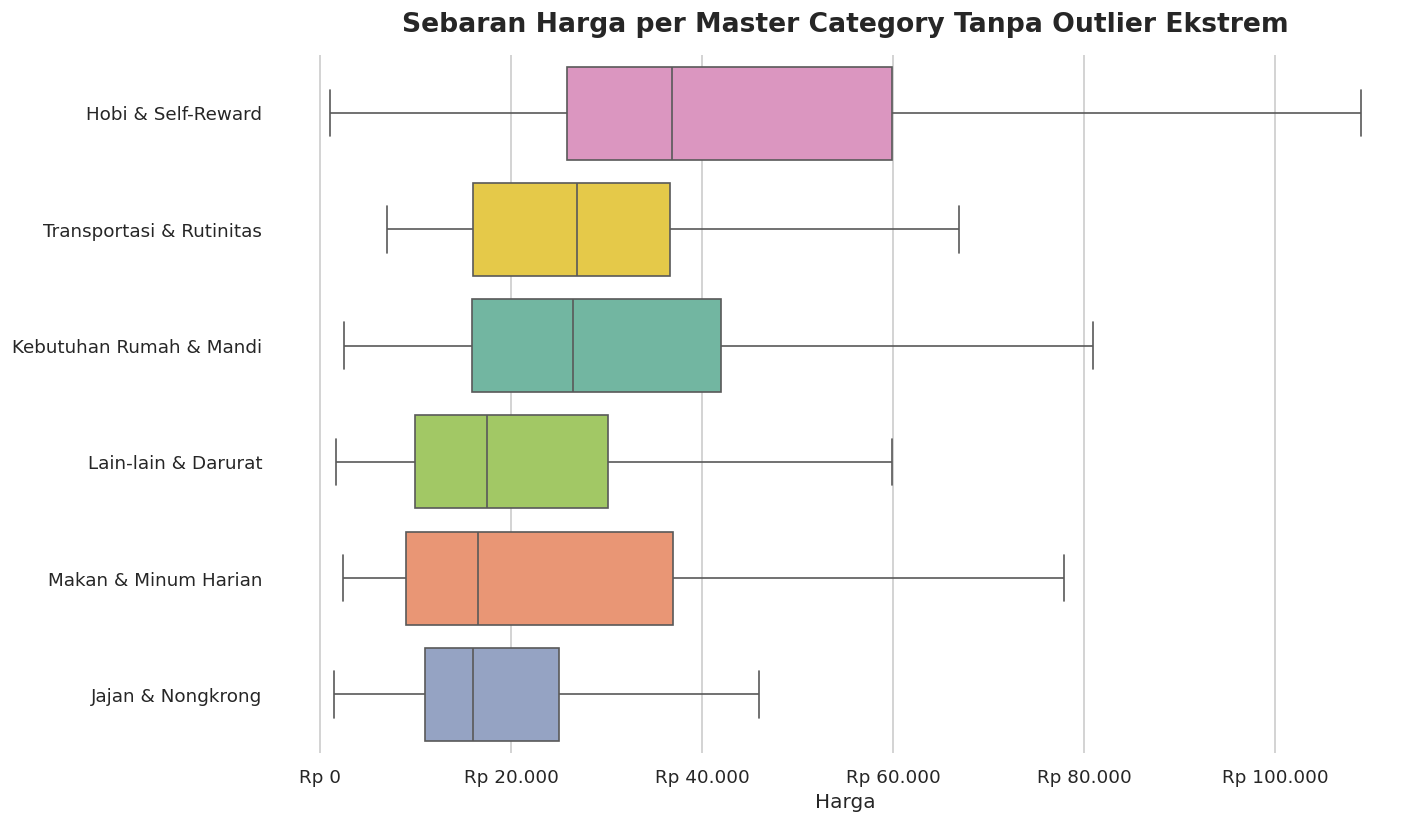

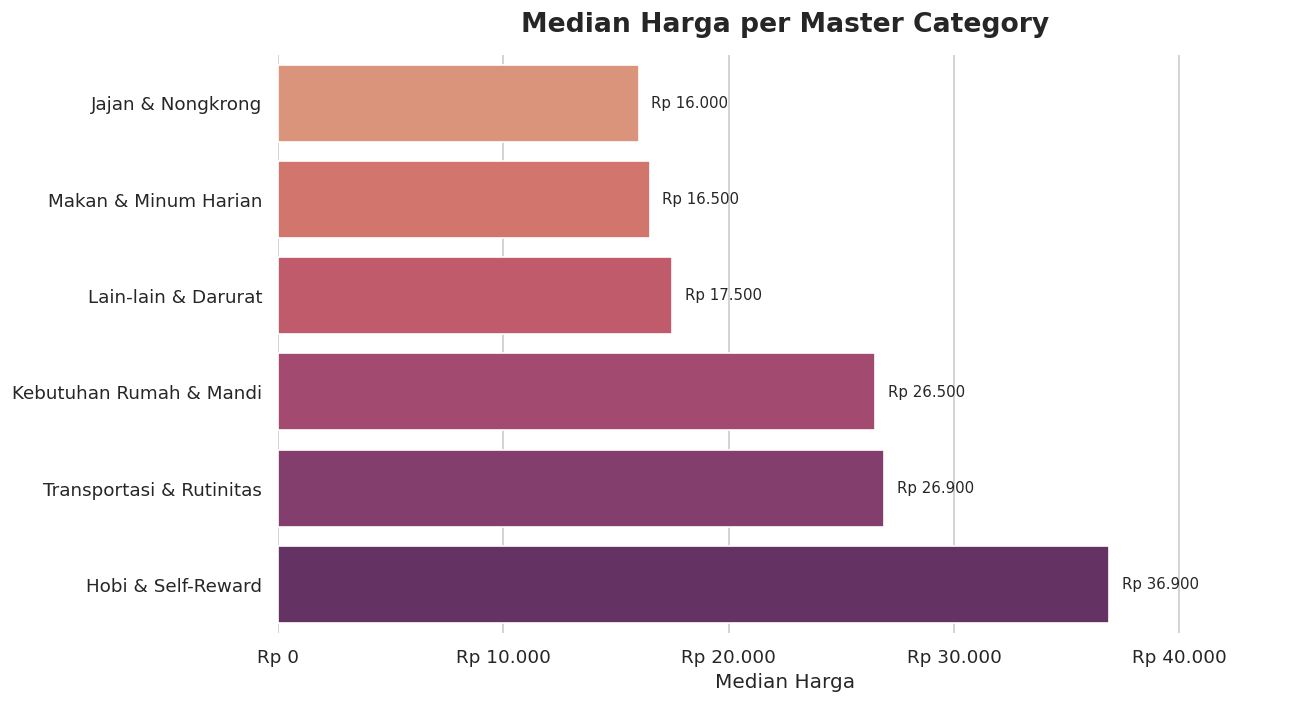

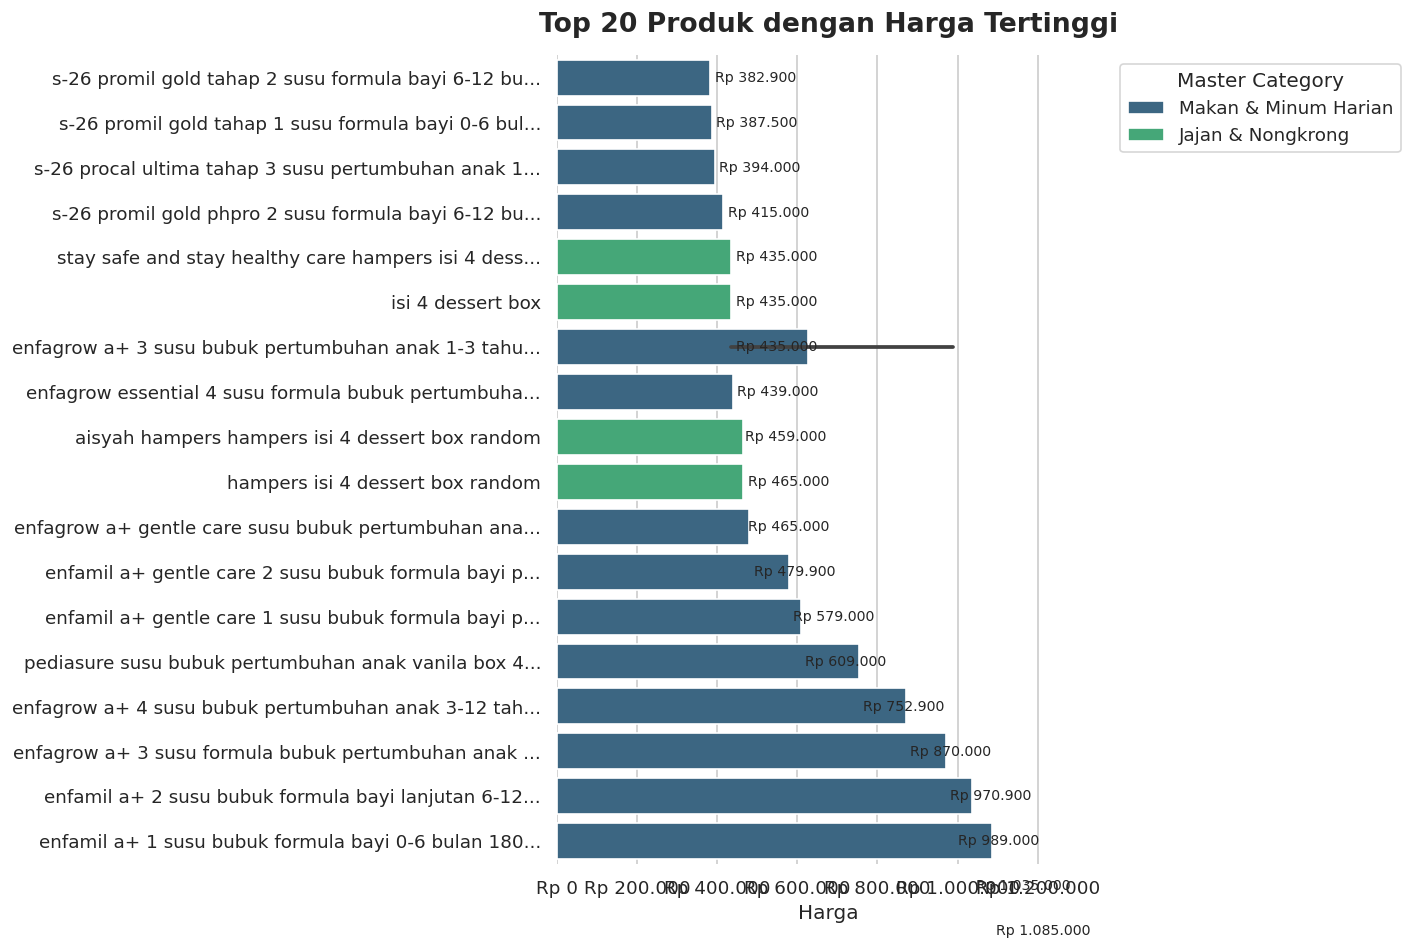

In [50]:
df_price = df_master[df_master["price_missing"] == False].copy()

price_order = (
    df_price
    .groupby("Master_Category")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=df_price,
    x="price",
    y="Master_Category",
    order=price_order,
    hue="Master_Category",
    legend=False,
    palette="Set2",
    showfliers=False
)

ax.set_title("Sebaran Harga per Master Category Tanpa Outlier Ekstrem", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Harga")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(rupiah_formatter))
sns.despine(left=True, bottom=True)
save_plot("06_price_boxplot_master_category.png")

median_price = (
    df_price
    .groupby("Master_Category")["price"]
    .median()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=median_price,
    x="price",
    y="Master_Category",
    hue="Master_Category",
    legend=False,
    palette="flare"
)

ax.set_title("Median Harga per Master Category", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Median Harga")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(rupiah_formatter))

for i, value in enumerate(median_price["price"]):
    ax.text(
        value + (median_price["price"].max() * 0.015),
        i,
        f"Rp {int(value):,}".replace(",", "."),
        va="center",
        fontsize=9
    )

ax.set_xlim(0, median_price["price"].max() * 1.22)
sns.despine(left=True, bottom=True)
save_plot("07_median_price_master_category.png")

top_expensive = (
    df_price
    .sort_values("price", ascending=False)
    .head(20)
    .copy()
)

top_expensive["short_name"] = top_expensive["product_clean"].apply(lambda x: shorten_text(x, 50))
top_expensive = top_expensive.sort_values("price")

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_expensive,
    x="price",
    y="short_name",
    hue="Master_Category",
    dodge=False,
    palette="viridis"
)

ax.set_title("Top 20 Produk dengan Harga Tertinggi", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Harga")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(rupiah_formatter))

for i, value in enumerate(top_expensive["price"]):
    ax.text(
        value + (top_expensive["price"].max() * 0.01),
        i,
        f"Rp {int(value):,}".replace(",", "."),
        va="center",
        fontsize=8.5
    )

ax.set_xlim(0, top_expensive["price"].max() * 1.25)
ax.legend(title="Master Category", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(left=True, bottom=True)
save_plot("08_top_20_expensive_products.png")

<Figure size 1560x720 with 0 Axes>

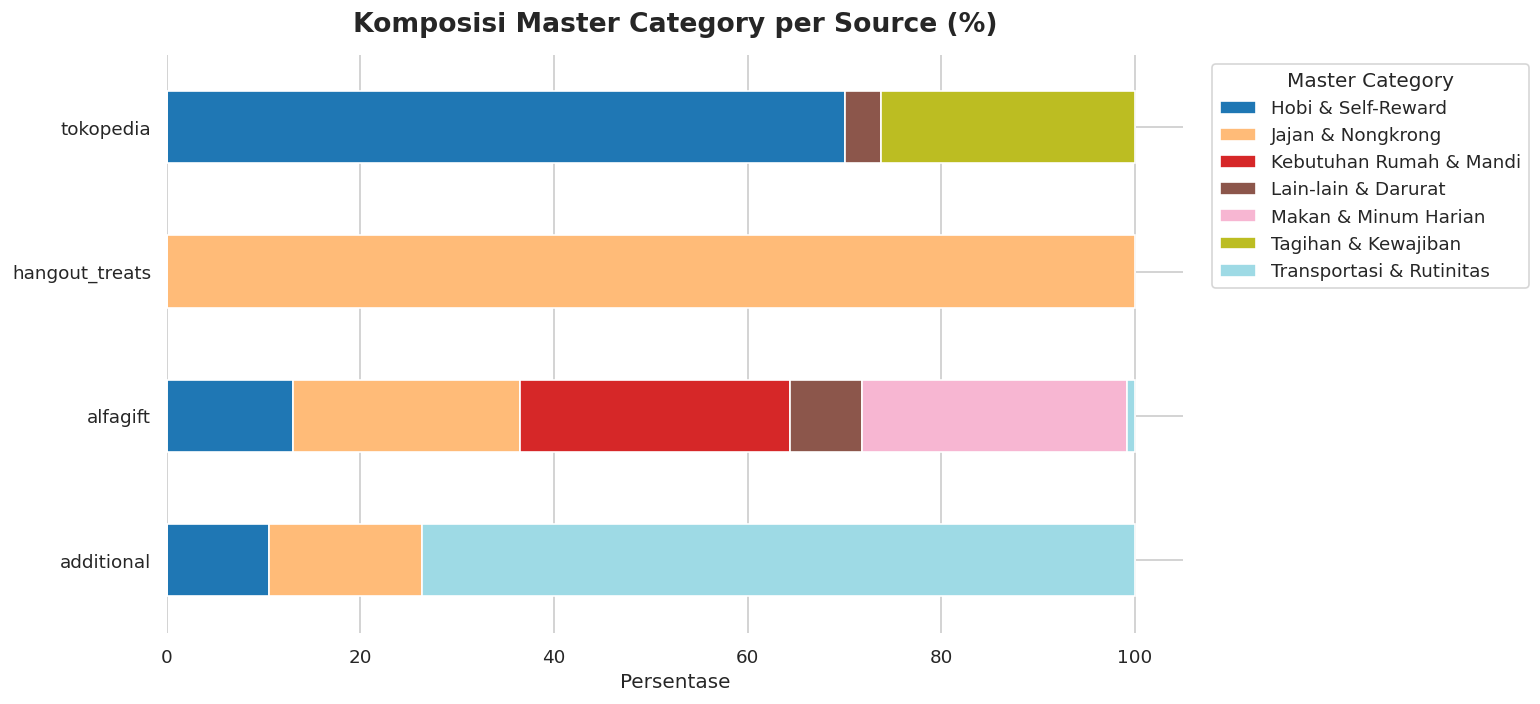

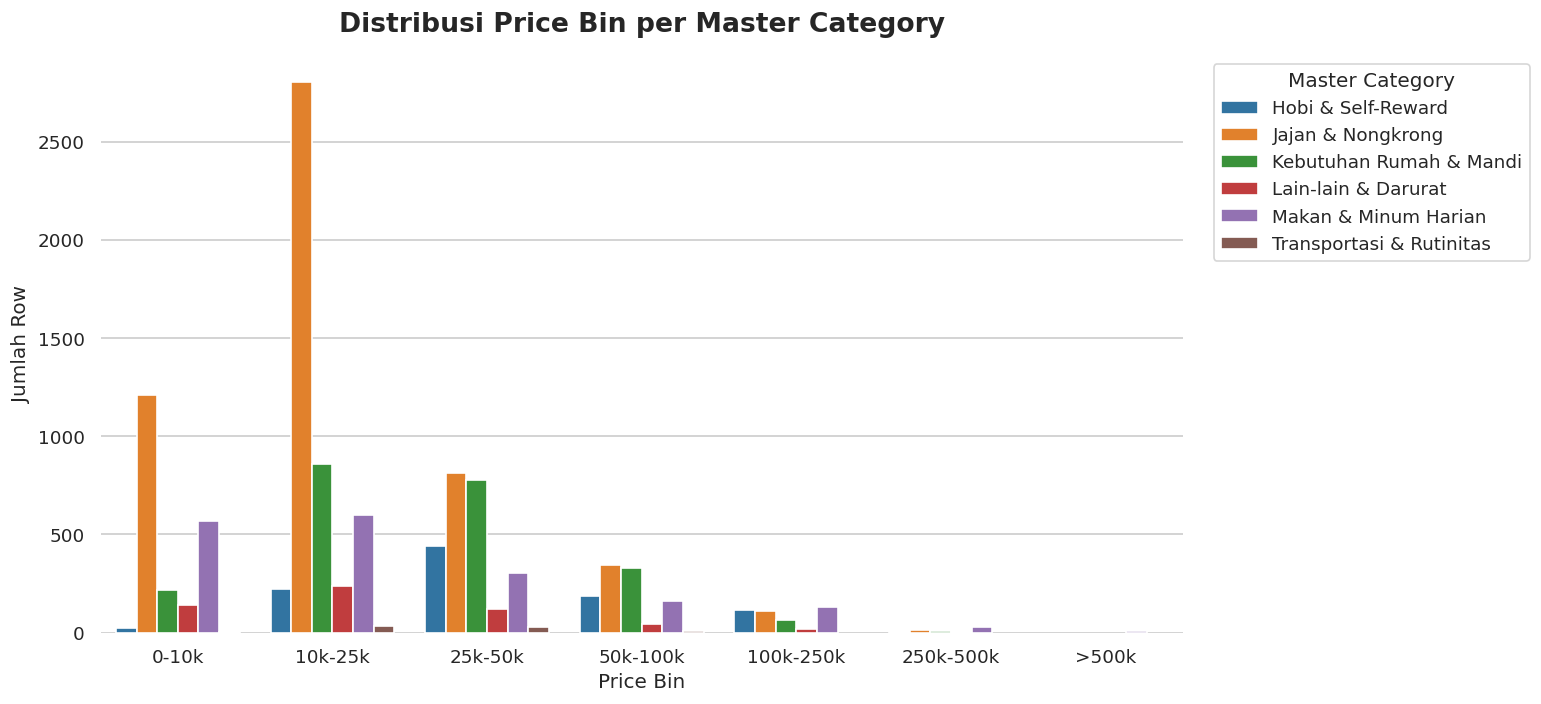

In [51]:
source_master = pd.crosstab(df_master["source"], df_master["Master_Category"])

source_master_pct = source_master.div(source_master.sum(axis=1), axis=0) * 100

plt.figure(figsize=(13, 6))
ax = source_master_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 6),
    colormap="tab20"
)

ax.set_title("Komposisi Master Category per Source (%)", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Persentase")
ax.set_ylabel("")
ax.legend(title="Master Category", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(left=True, bottom=True)
save_plot("09_source_master_category_stacked.png")

price_bin_counts = (
    df_price
    .groupby(["price_bin", "Master_Category"], observed=True)
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=price_bin_counts,
    x="price_bin",
    y="count",
    hue="Master_Category",
    palette="tab10"
)

ax.set_title("Distribusi Price Bin per Master Category", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Price Bin")
ax.set_ylabel("Jumlah Row")
ax.legend(title="Master Category", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(left=True, bottom=True)
save_plot("10_price_bin_distribution.png")

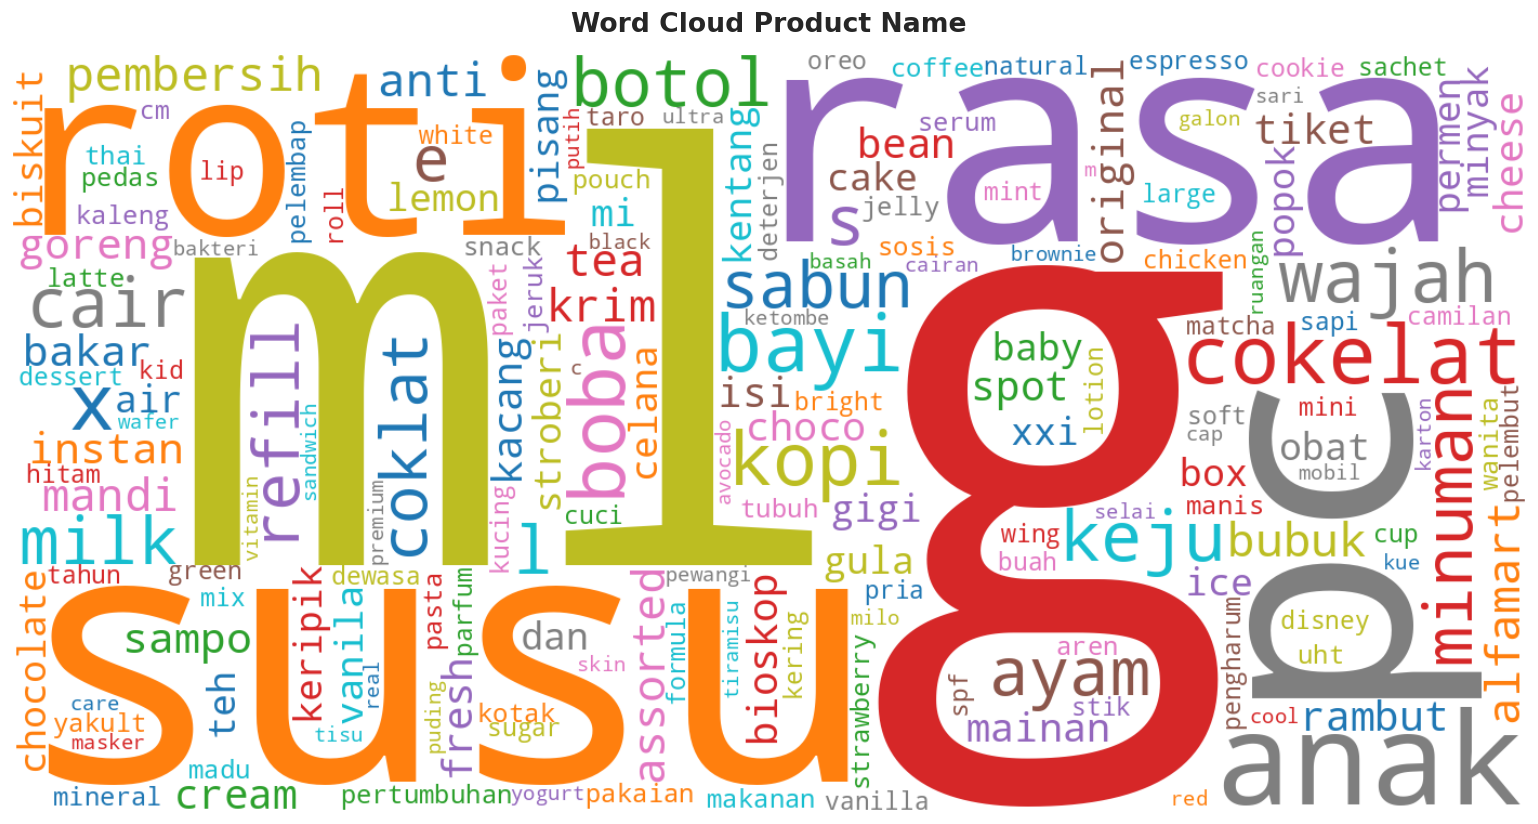

In [52]:
text_all = " ".join(df_master["product_clean"].dropna().astype(str))

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=180,
    colormap="tab10",
    collocations=False
).generate(text_all)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Product Name", fontsize=16, fontweight="bold", pad=14)
save_plot("11_wordcloud_product_name.png")

In [53]:
print("=" * 90)
print("SPRINT 1 AUTO INSIGHT")
print("=" * 90)

print("\n1. Dataset Size")
print(f"- Raw rows              : {len(df_raw):,}")
print(f"- Removed rows          : {len(df_removed):,}")
print(f"- Master rows           : {len(df_master):,}")
print(f"- AI-ready rows         : {len(df_ai):,}")
print(f"- Rows dengan harga     : {len(df_price_only):,}")
print(f"- Rows harga kosong     : {df_master['price_missing'].sum():,}")

print("\n2. Macro Category")
display(df_master["Macro_Category"].value_counts().to_frame("total_rows"))

print("\n3. Master Category")
display(df_master["Master_Category"].value_counts().to_frame("total_rows"))

print("\n4. Source Contribution")
display(df_master["source"].value_counts().to_frame("total_rows"))

print("\n5. Label Confidence")
display(df_master["label_confidence"].value_counts().to_frame("total_rows"))

print("\n6. Statistik Harga per Master Category")
display(
    df_price
    .groupby("Master_Category")["price"]
    .describe()
    .round(0)
)

print("\n7. Sample AI Dataset")
display(df_ai.sample(min(25, len(df_ai)), random_state=42))

SPRINT 1 AUTO INSIGHT

1. Dataset Size
- Raw rows              : 13,262
- Removed rows          : 733
- Master rows           : 12,429
- AI-ready rows         : 12,429
- Rows dengan harga     : 10,969
- Rows harga kosong     : 1,460

2. Macro Category


,total_rows
Macro_Category,
WANTS,6880
NEEDS,4904
OTHERS,645



3. Master Category


,total_rows
Master_Category,
Jajan & Nongkrong,5637
Kebutuhan Rumah & Mandi,2411
Makan & Minum Harian,2369
Hobi & Self-Reward,1243
Lain-lain & Darurat,645
Transportasi & Rutinitas,81
Tagihan & Kewajiban,43



4. Source Contribution


...

,total_rows
label_confidence,
high,12429



6. Statistik Harga per Master Category


,count,mean,std,min,25%,50%,75%,max
Master_Category,,,,,,,,
Hobi & Self-Reward,989.0,51278.0,42004.0,1000.0,25900.0,36900.0,59900.0,359000.0
Jajan & Nongkrong,5295.0,24886.0,31370.0,1500.0,11000.0,16000.0,25000.0,465000.0
Kebutuhan Rumah & Mandi,2253.0,34138.0,29397.0,2500.0,15900.0,26500.0,42000.0,279900.0
Lain-lain & Darurat,562.0,28259.0,35449.0,1700.0,10000.0,17500.0,30175.0,277700.0
Makan & Minum Harian,1803.0,39723.0,78661.0,2400.0,9000.0,16500.0,37000.0,1085000.0
Transportasi & Rutinitas,67.0,29427.0,18610.0,7000.0,16050.0,26900.0,36650.0,100000.0



7. Sample AI Dataset


,product_clean,price,price_missing,raw_category_refined,Macro_Category,Master_Category,label_confidence,source
12278,langganan,NaN,True,bills & obligations,NEEDS,Tagihan & Kewajiban,high,tokopedia
9622,1bungkus jamur shimeji,18000.0,False,dessert,WANTS,Jajan & Nongkrong,high,hangout_treats
11161,abc baterai aa biru r-6 4 pcs,NaN,True,household & personal care,NEEDS,Kebutuhan Rumah & Mandi,high,alfagift
12385,starmaker global,NaN,True,digital entertainment,WANTS,Hobi & Self-Reward,high,tokopedia
12033,himalaya herbals men pembersih wajah intense o...,NaN,True,household & personal care,NEEDS,Kebutuhan Rumah & Mandi,high,alfagift
2439,chiki balls makanan ringan cheeky chicken 50 g,7200.0,False,makanan,WANTS,Jajan & Nongkrong,high,alfagift
5928,wardah glasting lip liquid 02 peach polish 3.5 g,83000.0,False,beauty / self care,WANTS,Hobi & Self-Reward,high,alfagift
1114,makuku sap comfort fit popok perekat bayi nb 4...,52900.0,False,household & personal care,NEEDS,Kebutuhan Rumah & Mandi,high,alfagift
12179,disney puzzle mainan anak d100s1 assorted,NaN,True,lifestyle / self reward,WANTS,Hobi & Self-Reward,high,alfagift
8736,perpaduan thai tea ala kopi kanto denganyakult...,21000.0,False,milk tea,WANTS,Jajan & Nongkrong,high,hangout_treats


In [54]:
with zipfile.ZipFile(ZIP_OUTPUT, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in OUTPUT_DIR.rglob("*"):
        if file.is_file():
            zipf.write(file, arcname=file.relative_to(OUTPUT_DIR.parent))

print(f"ZIP created: {ZIP_OUTPUT}")

from google.colab import files

files.download(ZIP_OUTPUT)
files.download(str(AI_OUTPUT))
files.download(str(MASTER_OUTPUT))

ZIP created: sprint1_final_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>